In [225]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib

In [226]:
obs = pd.read_csv('observations.csv')
spcs = pd.read_csv('species_info.csv')

print(obs.columns)

Index(['scientific_name', 'park_name', 'observations'], dtype='object')


In [227]:
print(spcs.columns)

Index(['category', 'scientific_name', 'common_names', 'conservation_status'], dtype='object')


In [228]:
species_unique = list(spcs.category.unique())
print(species_unique)

['Mammal', 'Bird', 'Reptile', 'Amphibian', 'Fish', 'Vascular Plant', 'Nonvascular Plant']


In [229]:
obs.park_name = obs.park_name.str.replace('National Park', '', case = False)
parks_unique = list(obs.park_name.unique())
print(parks_unique)

['Great Smoky Mountains ', 'Yosemite ', 'Bryce ', 'Yellowstone ']


In [230]:
sci_name_unique_obs = list(obs.scientific_name.unique())
# print(sci_name_unique_obs)
# Way too many species, comparisons unlikely

In [231]:
sci_name_unique_spcs = list(spcs.scientific_name.unique())
# print(sci_name_unique_spcs)
# Way too many species, comparisons unlikely

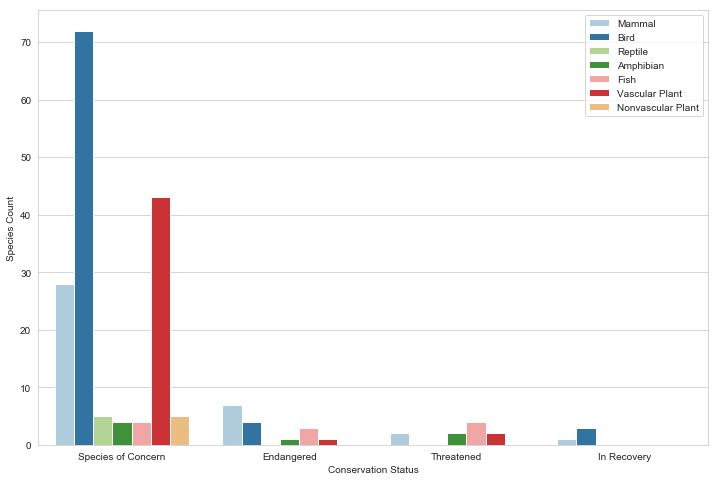

In [232]:
plt.figure(figsize = (12,8))
sns.set_palette('Paired')
sns.set_style('whitegrid')
sns.countplot(data = spcs, x = 'conservation_status', hue = 'category')
plt.legend(loc = 1)
plt.xlabel('Conservation Status')
plt.ylabel('Species Count')
plt.show()

# Clean representation of the conservation status of many species.

In [233]:
spcs = spcs.replace(np.nan, 'No Intervention')
# print(spcs)

In [234]:
conserve_unique = list(spcs.conservation_status.unique())
print(np.sort((conserve_unique)))

['Endangered' 'In Recovery' 'No Intervention' 'Species of Concern'
 'Threatened']


In [235]:
count_conv = spcs[spcs.conservation_status != 'No Intervention'].groupby([ 'conservation_status','category'])['common_names'].count().unstack()
# print((count_conv.loc['Amphibian']))
count_conv = count_conv.replace(np.nan, 0)
count_conv

category,Amphibian,Bird,Fish,Mammal,Nonvascular Plant,Reptile,Vascular Plant
conservation_status,,,,,,,
Endangered,1.0,4.0,3.0,7.0,0.0,0.0,1.0
In Recovery,0.0,3.0,0.0,1.0,0.0,0.0,0.0
Species of Concern,4.0,72.0,4.0,28.0,5.0,5.0,43.0
Threatened,2.0,0.0,4.0,2.0,0.0,0.0,2.0


In [236]:
count_general = spcs.groupby(['category','conservation_status'])['common_names'].count().unstack()
count_general = count_general.replace(np.nan, 0)
count_general.sum()

conservation_status
Endangered              16.0
In Recovery              4.0
No Intervention       5633.0
Species of Concern     161.0
Threatened              10.0
dtype: float64

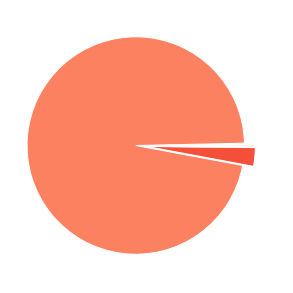

In [237]:
plt.figure(figsize = (5,5))
sns.set_palette('Reds')
plt.pie(count_general.sum(), explode = [0,0,.1,0,0])
plt.show()

# Messy representation of how there are many species without intervention. This may be because no intervention is needed
# or potentially another reason, not enough data to know the circumstance.

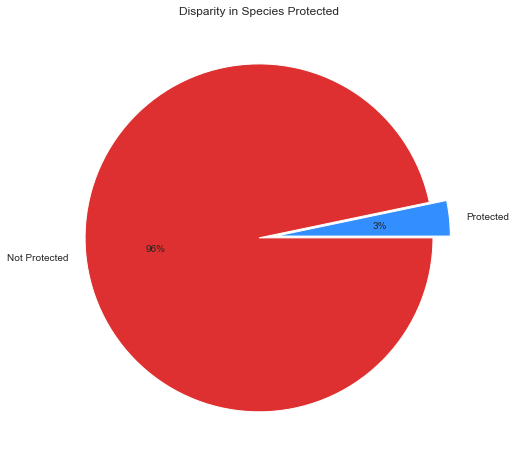

In [238]:
protect = spcs.conservation_status != 'No Intervention'


x = 0
y = 0
for i in protect:
    if i == True:
        x += 1
    else:
        y += 1

protected = [x,y]

plt.figure(figsize = (8,8))
plt.pie(protected, autopct = '%1d%%', explode = [0.1,0], colors = ['#338eff', '#de3030'], labels = ['Protected', 'Not Protected'])
plt.title('Disparity in Species Protected')
plt.show()

#  Disparity in protection shown more clearly. This may be because no intervention is needed
# or potentially another reason, not enough data to know the circumstance.

In [239]:
# Attempt to merge dataframes in order to explore individual species.
duplicates_spcs = (spcs[spcs.scientific_name.duplicated(keep = False)])
spcs.drop_duplicates(inplace=True, subset='scientific_name', keep='first')
spcs.reset_index(drop=True, inplace=True)

spcs_obs = spcs.merge(obs, on = 'scientific_name', how = 'outer')
spcs_obs

,category,scientific_name,common_names,conservation_status,park_name,observations
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,No Intervention,Bryce,130
1,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,No Intervention,Yellowstone,270
2,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,No Intervention,Great Smoky Mountains,98
3,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,No Intervention,Yosemite,117
4,Mammal,Bos bison,"American Bison, Bison",No Intervention,Yosemite,128
5,Mammal,Bos bison,"American Bison, Bison",No Intervention,Yellowstone,269
6,Mammal,Bos bison,"American Bison, Bison",No Intervention,Bryce,68
7,Mammal,Bos bison,"American Bison, Bison",No Intervention,Great Smoky Mountains,77
8,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",No Intervention,Bryce,99
9,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",No Intervention,Yosemite,124


In [240]:
cat_obs = spcs_obs[['category', 'observations']].groupby('category').sum().sort_values('observations', ascending = False).reset_index()
cat_obs

,category,observations
0,Vascular Plant,2555090
1,Bird,292833
2,Nonvascular Plant,190653
3,Mammal,116696
4,Fish,70818
5,Reptile,44678
6,Amphibian,43971


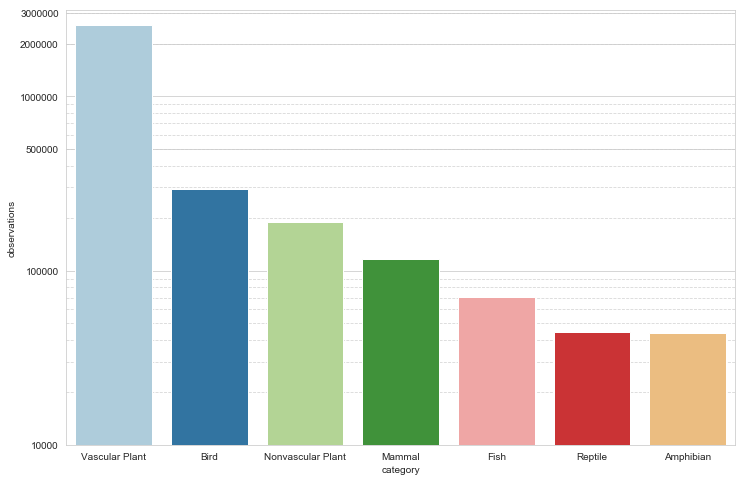

In [241]:
plt.figure(figsize = (12,8))
ax1 = plt.subplot()
sns.set_palette('Paired')
sns.set_style('whitegrid')
sns.barplot(data = cat_obs, x = 'category', y = 'observations')
plt.grid(b=True, which='minor', linestyle='--', alpha=0.8)
ax1.set_yscale('log')
ax1.set_yticks([10000,100000,500000, 1000000,2000000,3000000])
ax1.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
plt.show()

# Shows the distribution of the species obserevd with vascular plants dominating. log scale to better show the rest.

In [242]:
park_obs = spcs_obs[['park_name','category','observations']].groupby('park_name').sum().reset_index()
park_obs

,park_name,observations
0,Bryce,576025
1,Great Smoky Mountains,431820
2,Yellowstone,1443562
3,Yosemite,863332


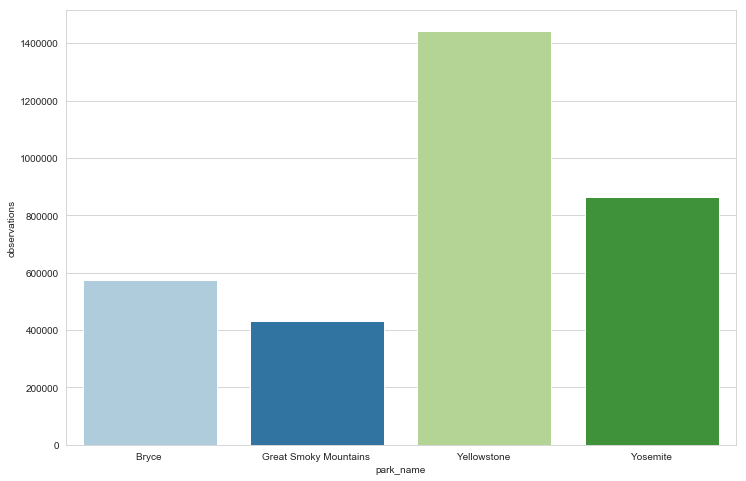

In [243]:
plt.figure(figsize = (12,8))
ax1 = plt.subplot()
sns.set_palette('Paired')
sns.set_style('whitegrid')
sns.barplot(data = park_obs, x = 'park_name', y = 'observations')
plt.show()

In [244]:
park_obs_cat = spcs_obs[['park_name','category','observations']].groupby(['park_name','category']).sum().reset_index()
park_obs_cat.head()

,park_name,category,observations
0,Bryce,Amphibian,7380
1,Bryce,Bird,51647
2,Bryce,Fish,12423
3,Bryce,Mammal,20550
4,Bryce,Nonvascular Plant,32992


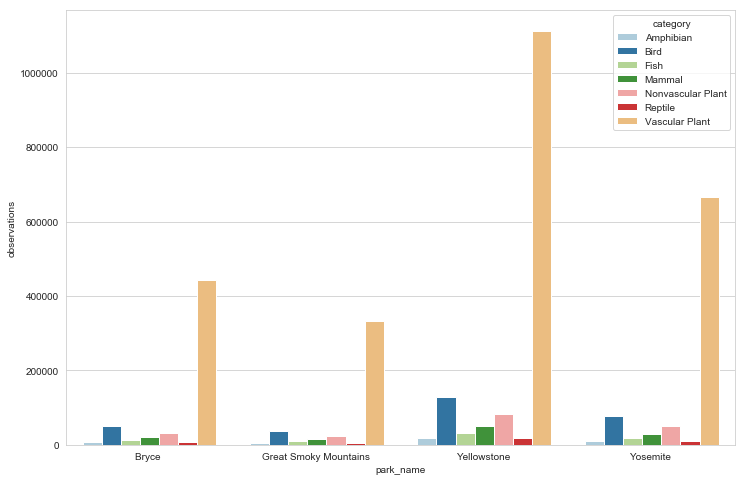

In [245]:
plt.figure(figsize = (12,8))
ax1 = plt.subplot()
sns.set_palette('Paired')
sns.set_style('whitegrid')
sns.barplot(data = park_obs_cat, x = 'park_name', y = 'observations', hue = 'category')
plt.show()

In [246]:
before_num = []
before_denom = []

for i in range(len(park_obs_cat)):
    before_num.append(park_obs_cat.iloc[i][2])
for i in range(len(park_obs)):
    before_denom.append(park_obs.iloc[i][1])
    
# print(before_num)
# print(before_denom)

percentages = []

for i in range(0,7):
    percentages.append((before_num[i]/before_denom[0])*100)
for i in range(7,14):
    percentages.append((before_num[i]/before_denom[1])*100)
for i in range(14,21):
    percentages.append((before_num[i]/before_denom[2])*100)
for i in range(21,28):
    percentages.append((before_num[i]/before_denom[3])*100)
    
# print(percentages)

In [247]:
park_obs_cat['percentage'] = percentages

In [248]:
park_obs_cat.head()

,park_name,category,observations,percentage
0,Bryce,Amphibian,7380,1.281194
1,Bryce,Bird,51647,8.966104
2,Bryce,Fish,12423,2.156677
3,Bryce,Mammal,20550,3.567553
4,Bryce,Nonvascular Plant,32992,5.727529


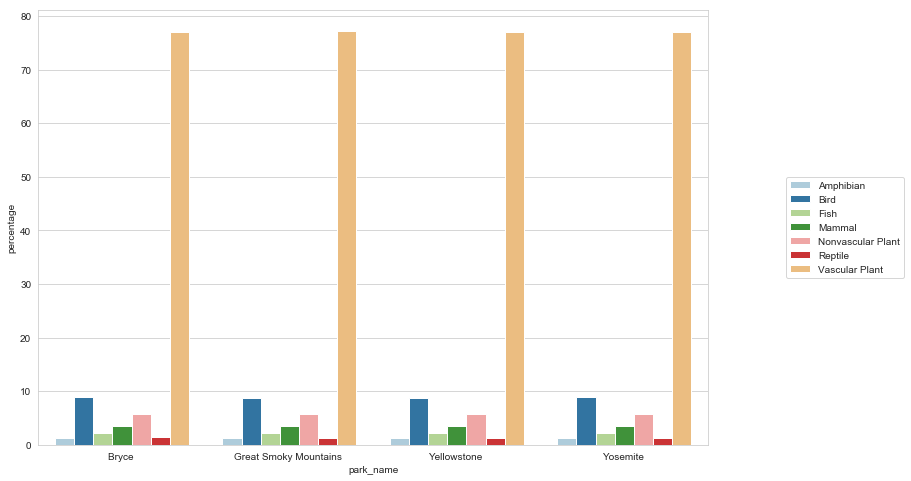

In [282]:
plt.figure(figsize = (12,8))
ax1 = plt.subplot()
sns.set_palette('Paired')
sns.set_style('whitegrid')
sns.barplot(data = park_obs_cat, x = 'park_name', y = 'percentage', hue = 'category')
plt.legend(loc= 7, bbox_to_anchor=(1.3,0.5))
plt.show()
# This shows the data is most likely fictional as the percentages are enarly identical. So the observations seems to be
# proportionally dictated across the differnet parks.

In [258]:
spcs_obs_conv = spcs_obs[spcs_obs['conservation_status'] != 'No Intervention']
spcs_obs['common_names'] = spcs_obs['common_names'].str.replace(',', '')

In [259]:
len(spcs_obs_conv['common_names'].unique())

178

In [263]:
species_count = spcs_obs_conv.common_names.str.split(expand=True).stack().value_counts()
print(species_count.head(20))

Myotis        96
Bat           60
Brown         40
Northern      28
Mountain      28
American      28
California    28
Little        24
Hawk          16
Common        16
Western       16
Warbler       16
Long-Eared    16
Gray          16
Nevada        16
Sparrow       16
Badger        16
Wolf          16
Sierra        16
Snake         16
dtype: int64


In [268]:
bat = spcs_obs[spcs_obs['common_names'].str.contains('Bat')]
bat.head()

,category,scientific_name,common_names,conservation_status,park_name,observations
168,Mammal,Corynorhinus rafinesquii,Rafinesque's Big-Eared Bat,No Intervention,Yosemite,188
169,Mammal,Corynorhinus rafinesquii,Rafinesque's Big-Eared Bat,No Intervention,Great Smoky Mountains,80
170,Mammal,Corynorhinus rafinesquii,Rafinesque's Big-Eared Bat,No Intervention,Bryce,57
171,Mammal,Corynorhinus rafinesquii,Rafinesque's Big-Eared Bat,No Intervention,Yellowstone,259
172,Mammal,Eptesicus fuscus,Big Brown Bat,Species of Concern,Yellowstone,227


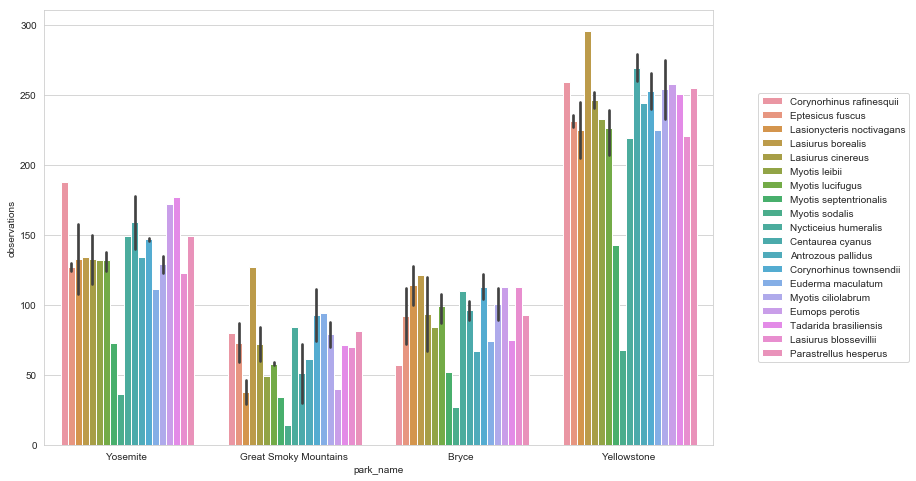

In [283]:
plt.figure(figsize = (12,8))
ax1 = plt.subplot()
sns.set_palette('Paired')
sns.set_style('whitegrid')
sns.barplot(data = bat, x = 'park_name', y = 'observations', hue = 'scientific_name')
plt.legend(loc= 7, bbox_to_anchor=(1.3,0.5))
plt.show()

# This shows that bats of all types are msot prevalent at yellowstone national park

# Obviously all the graphs made could be polished with x and y labels and titles but I have grown rather bored with this dataframe